# Prediction of the Algorithm

In [76]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from tabulate import tabulate
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from matplotlib.colors import LinearSegmentedColormap
import ast
import seaborn as sns
from matplotlib import colors as mcolors

DATASET_FOLDER = "../data"
TEST_FOLDER = "../tests"

import warnings
warnings.filterwarnings("ignore", category=UserWarning)

In [77]:
data = pd.read_csv("../results/metrics.csv")

columns = [
"Dataset","Algorithm","Grid Size","Total Placements",
"Residential","Utility","Score","Time (s)","Peak Memory (MB)","Parameters"
]

df = pd.DataFrame(data, columns=columns)

In [78]:
def predict_with_range(model, X, multiplier=5.7):

    tree_preds = np.array([tree.predict(X)[0] for tree in model.estimators_])

    mean_pred = tree_preds.mean()
    std_pred = tree_preds.std()

    lower = mean_pred - multiplier * std_pred
    upper = mean_pred + multiplier * std_pred

    return mean_pred, lower, upper

In [79]:
def extract_dataset_features(filepath):
    with open(filepath, "r") as f:
        lines = f.read().strip().split("\n")

    # First line: H, W, D, B
    H, W, D, B = map(int, lines[0].split())
    projects = lines[1:]

    i = 0
    residential_areas, residential_caps = [], []
    utility_areas, utility_services = [], set()

    residential_density, utility_density = [], []

    while i < len(projects):
        parts = projects[i].split()
        p_type, h, w, value = parts[0], int(parts[1]), int(parts[2]), int(parts[3])
        area = h * w

        footprint_lines = projects[i+1:i+1+h]
        occupied_blocks = sum(line.count("#") for line in footprint_lines)
        density = occupied_blocks / (h*w)

        if p_type == "R":
            residential_areas.append(area)
            residential_caps.append(value)
            residential_density.append(density)
        else:  # Utility
            utility_areas.append(area)
            utility_services.add(value)
            utility_density.append(density)

        i += 1 + h  # skip footprint lines

    return {
        "Dataset": os.path.splitext(os.path.basename(filepath))[0],
        "grid_height": H,
        "grid_width": W,
        "grid_area": H * W,
        "max_distance": D,
        "num_projects": B,
        "num_residential_projects": len(residential_areas),
        "num_utility_projects": len(utility_areas),
        "avg_residential_area": sum(residential_areas) / len(residential_areas) if residential_areas else 0,
        "max_residential_area": max(residential_areas) if residential_areas else 0,
        "avg_residential_capacity": sum(residential_caps) / len(residential_caps) if residential_caps else 0,
        "avg_utility_area": sum(utility_areas) / len(utility_areas) if utility_areas else 0,
        "max_utility_area": max(utility_areas) if utility_areas else 0,
        "num_service_types": len(utility_services),
        "avg_residential_density": sum(residential_density) / len(residential_density) if residential_density else 0,
        "max_residential_density": max(residential_density) if residential_density else 0,
        "avg_utility_density": sum(utility_density) / len(utility_density) if utility_density else 0,
        "max_utility_density": max(utility_density) if utility_density else 0,
    }


# Extract features for all datasets
dataset_features = []

for file in os.listdir(DATASET_FOLDER):
    path = os.path.join(DATASET_FOLDER, file)
    if os.path.isfile(path):
        dataset_features.append(extract_dataset_features(path))

features_df = pd.DataFrame(dataset_features)

# Merge with your existing df
df = df.merge(features_df, on="Dataset", how="left")

df = df[df["Dataset"] != "a_example"]

print(df.head())

        Dataset      Algorithm  Grid Size  Total Placements  Residential  \
5  b_short_walk  hill_climbing  1000x1000            103780        20886   
6  b_short_walk  hill_climbing  1000x1000            103780        20886   
7  b_short_walk  hill_climbing  1000x1000            103780        20886   
8  b_short_walk  hill_climbing  1000x1000            103780        20886   
9  b_short_walk  hill_climbing  1000x1000            103780        20886   

   Utility    Score  Time (s)  Peak Memory (MB)  \
5    82894  1807423  519.4268          220.3475   
6    82894  1807423  500.0384          220.3478   
7    82894  1807423  494.1642          220.1269   
8    82894  1807423  497.6014          220.1269   
9    82894  1807423  494.4644          220.1269   

                                          Parameters  ...  \
5  max_iterations=5000, patience=500, min_delta=2...  ...   
6  max_iterations=5000, patience=500, min_delta=2...  ...   
7  max_iterations=5000, patience=500, min_delta=2... 

## Training

In [80]:
if "Grid Size" in df.columns:
    df[['Grid_H', 'Grid_W']] = df['Grid Size'].str.split('x', expand=True).astype(int)

# One-Hot Encoding for categorical variables (Dataset e Algorithm)
df_encoded = pd.get_dummies(df, columns=["Algorithm"])

cols_to_drop = [
    "Dataset", "Score", "Grid Size", "Parameters",
    "Total Placements", "Residential", "Utility",
    "Time (s)", "Peak Memory (MB)"
]
if "Timestamp" in df_encoded.columns:
    cols_to_drop.append("Timestamp")

X = df_encoded.drop(columns=cols_to_drop, errors='ignore')
y = df_encoded["Score"]

X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y, df.index, test_size=0.2, random_state=42
)

model = RandomForestRegressor(
    n_estimators=200,
    max_depth=12,
    n_jobs=-1,
    random_state=42
)
model.fit(X_train, y_train)

pred = model.predict(X_test)

results = df.loc[idx_test].copy()
results["Predicted_Score"] = pred.astype(int)
results["Original_Score"] = y_test.values

results["Error (%)"] = ((abs(results["Original_Score"] - results["Predicted_Score"]) / results["Original_Score"]) * 100).round(2).astype(str) + "%"

results_display = results[["Dataset", "Algorithm", "Original_Score", "Predicted_Score", "Error (%)"]]

print("\n" + "="*80)
print("Surrogate Model: Random Forest Regressor")
print("="*80)

print(tabulate(results_display.head(20), headers='keys', tablefmt='fancy_grid', showindex=False))

print("\nGlobal Metrics:")
print(f"-> MAE (Mean Absolute Error): {mean_absolute_error(y_test, pred):.2f}")
print(f"-> R²  (Precision of the Model): {r2_score(y_test, pred):.4f}")
print("="*80 + "\n")


Surrogate Model: Random Forest Regressor
╒════════════════════════╤═════════════════════╤══════════════════╤═══════════════════╤═════════════╕
│ Dataset                │ Algorithm           │   Original_Score │   Predicted_Score │ Error (%)   │
╞════════════════════════╪═════════════════════╪══════════════════╪═══════════════════╪═════════════╡
│ b_short_walk           │ genetic_algorithm   │          1804115 │           1814803 │ 0.59%       │
├────────────────────────┼─────────────────────┼──────────────────┼───────────────────┼─────────────┤
│ b_short_walk           │ genetic_algorithm   │          1817228 │           1814803 │ 0.13%       │
├────────────────────────┼─────────────────────┼──────────────────┼───────────────────┼─────────────┤
│ f_different_footprints │ genetic_algorithm   │          2194954 │           2016287 │ 8.14%       │
├────────────────────────┼─────────────────────┼──────────────────┼───────────────────┼─────────────┤
│ e_precise_fit          │ genetic_algor

## Test

In [81]:
known_algorithms = df['Algorithm'].unique()
predictions = []

print(f"Analyzing new maps in folder '{TEST_FOLDER}'...\n")

for filename in os.listdir(TEST_FOLDER):
    if filename.endswith(".in"):

        filepath = os.path.join(TEST_FOLDER, filename)

        features = extract_dataset_features(filepath)

        for algo in known_algorithms:

            input_dict = features.copy()
            input_dict["Algorithm"] = algo

            input_data = pd.DataFrame([input_dict])

            input_encoded = pd.get_dummies(input_data, columns=['Algorithm'])
            input_encoded = input_encoded.reindex(columns=X_train.columns, fill_value=0)

            mean_pred, lower, upper = predict_with_range(model, input_encoded)

            pred_score = int(mean_pred)
            lower = int(lower)
            upper = int(upper)

            predictions.append({
                "Test File": filename,
                "Algorithm": algo,
                "Predicted Score": pred_score,
                "Expected Min": lower,
                "Expected Max": upper
            })

results_df = pd.DataFrame(predictions)
results_df = results_df.sort_values(by=["Test File", "Predicted Score"], ascending=[True, False])

# 1: Everything (All Algorithms)
print("="*80)
print("Predictions for New Maps:")
print("="*80)
print(tabulate(results_df, headers='keys', tablefmt='fancy_grid', showindex=False))
print("\n")

# 2: Best Algorithm per Map
best_algorithms_df = results_df.drop_duplicates(subset=["Test File"], keep="first")
best_algorithms_df = best_algorithms_df.rename(columns={"Algorithm": "Recommended Algorithm", "Predicted Score": "Expected Score"})

print("="*80)
print("Recommended Algorithm for Each New Map:")
print("="*80)
print(tabulate(best_algorithms_df, headers='keys', tablefmt='fancy_grid', showindex=False))
print("="*80)

Analyzing new maps in folder '../tests'...

Predictions for New Maps:
╒═══════════════════════╤═════════════════════╤═══════════════════╤════════════════╤════════════════╕
│ Test File             │ Algorithm           │   Predicted Score │   Expected Min │   Expected Max │
╞═══════════════════════╪═════════════════════╪═══════════════════╪════════════════╪════════════════╡
│ g_joindb.in           │ tabu_search         │           2208140 │        1965200 │        2451081 │
├───────────────────────┼─────────────────────┼───────────────────┼────────────────┼────────────────┤
│ g_joindb.in           │ greedy              │           2096775 │        1743519 │        2450032 │
├───────────────────────┼─────────────────────┼───────────────────┼────────────────┼────────────────┤
│ g_joindb.in           │ genetic_algorithm   │           2084141 │        1558965 │        2609317 │
├───────────────────────┼─────────────────────┼───────────────────┼────────────────┼────────────────┤
│ g_joindb.i

## Disclosure


Detailed Accuracy Analysis (MAPE)
╒════════════════════╤═════════════════════╤══════════════╤═══════════════════╤═══════════╕
│ Test File          │ Algorithm           │   Real_Score │   Predicted Score │   Error % │
╞════════════════════╪═════════════════════╪══════════════╪═══════════════════╪═══════════╡
│ g_joindb           │ genetic_algorithm   │   1962280.00 │           2084141 │      6.21 │
├────────────────────┼─────────────────────┼──────────────┼───────────────────┼───────────┤
│ g_joindb           │ greedy              │   1859108.00 │           2096775 │     12.78 │
├────────────────────┼─────────────────────┼──────────────┼───────────────────┼───────────┤
│ g_joindb           │ hill_climbing       │   1900573.00 │           2081892 │      9.54 │
├────────────────────┼─────────────────────┼──────────────┼───────────────────┼───────────┤
│ g_joindb           │ simulated_annealing │   2422272.00 │           1964276 │     18.91 │
├────────────────────┼─────────────────────┼─

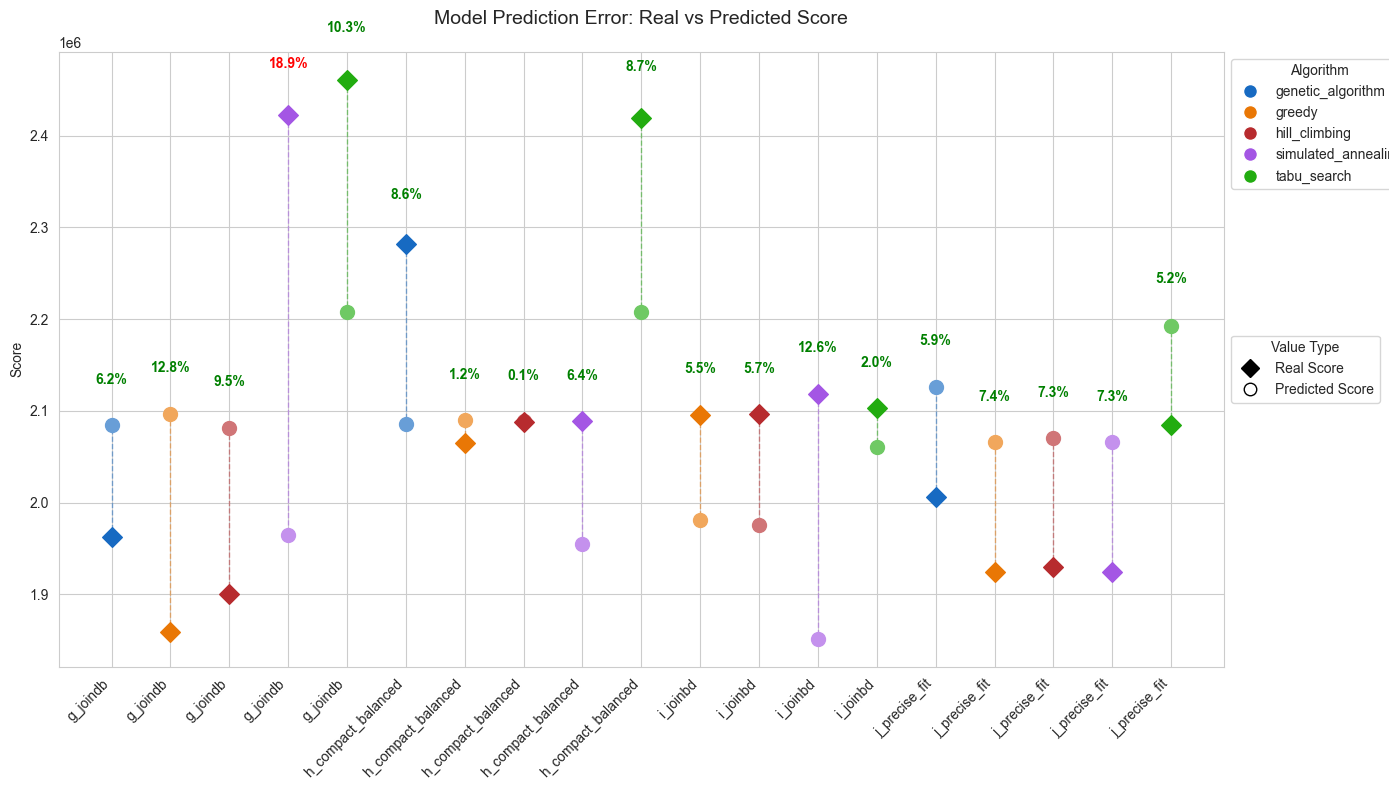

In [82]:
metrics_path = "../results/tests_metrics.csv"
real_scores_df = pd.read_csv(metrics_path)

real_scores_df["Dataset"] = real_scores_df["Dataset"].str.replace(".in", "", regex=False)
results_df["Test File"] = results_df["Test File"].str.replace(".in", "", regex=False)

comparison_df = results_df.merge(
    real_scores_df.rename(columns={"Score": "Real_Score"}),
    left_on=["Test File", "Algorithm"],
    right_on=["Dataset", "Algorithm"],
    how="left"
)

display_df = comparison_df[[
    "Test File",
    "Algorithm",
    "Real_Score",
    "Predicted Score"
]].copy()

# 1. Keep only rows that have Real_Score
eval_df = display_df.dropna(subset=["Real_Score"]).copy()

# 2. Calculate Absolute Percentage Error (APE)
eval_df["Error %"] = (
    abs(eval_df["Real_Score"] - eval_df["Predicted Score"]) / eval_df["Real_Score"]
) * 100

# 3. Fixed algorithm order
algorithm_order = [
    "genetic_algorithm",
    "greedy",
    "hill_climbing",
    "simulated_annealing",
    "tabu_search",
]

eval_df["Algorithm"] = pd.Categorical(
    eval_df["Algorithm"],
    categories=algorithm_order,
    ordered=True
)

eval_df = eval_df.sort_values(by=["Test File", "Algorithm"]).reset_index(drop=True)

eval_df["Label"] = eval_df["Test File"]

algorithm_colors = {
    "genetic_algorithm": "#176AC2",
    "greedy": "#E97705",
    "hill_climbing": "#B72B2E",
    "simulated_annealing": "#A456E4",
    "tabu_search": "#22AC10",
}

def lighten_color(color, amount=0.75):
    rgb = np.array(mcolors.to_rgb(color))
    white = np.array([1, 1, 1])
    return tuple(rgb + (white - rgb) * amount)

real_point_colors = {
    alg: algorithm_colors[alg]
    for alg in algorithm_order
}

pred_point_colors = {
    alg: lighten_color(algorithm_colors[alg], amount=0.35)
    for alg in algorithm_order
}

# Table
print("\n" + "=" * 80)
print("Detailed Accuracy Analysis (MAPE)")
print("=" * 80)

final_table_df = eval_df[[
    "Test File", "Algorithm", "Real_Score", "Predicted Score", "Error %"
]]
print(tabulate(final_table_df, headers="keys", tablefmt="fancy_grid", showindex=False, floatfmt=".2f"))

mape = eval_df["Error %"].mean()
print(f"-> Mean Absolute Percentage Error (MAPE): {mape:.2f}%")

# Plot
plt.figure(figsize=(14, 8))
sns.set_style("whitegrid")

x_indexes = np.arange(len(eval_df))

for i, row in eval_df.iterrows():
    alg = row["Algorithm"]

    plt.scatter(
        i,
        row["Real_Score"],
        color=real_point_colors[alg],
        zorder=5,
        s=100,
        marker="D"
    )

    plt.scatter(
        i,
        row["Predicted Score"],
        color=pred_point_colors[alg],
        zorder=4,
        s=100,
        marker="o"
    )

    plt.plot(
        [i, i],
        [row["Real_Score"], row["Predicted Score"]],
        color=algorithm_colors[alg],
        linestyle="--",
        alpha=0.5,
        linewidth=1,
        zorder=1
    )

    y_pos = max(row["Real_Score"], row["Predicted Score"])
    err_val = row["Error %"]

    plt.text(
        i,
        y_pos + (y_pos * 0.02),
        f"{err_val:.1f}%",
        ha="center",
        va="bottom",
        fontsize=10,
        weight="bold",
        color="red" if err_val > 15 else "green"
    )

plt.xticks(
    ticks=x_indexes,
    labels=eval_df["Label"],
    rotation=45,
    ha="right"
)

plt.title("Model Prediction Error: Real vs Predicted Score", pad=20, fontsize=14)
plt.ylabel("Score")

algorithm_handles = [
    Line2D(
        [0], [0],
        marker="o",
        color="w",
        label=alg,
        markerfacecolor=algorithm_colors[alg],
        markersize=10
    )
    for alg in algorithm_order
    if alg in eval_df["Algorithm"].astype(str).unique()
]

value_handles = [
    Line2D(
        [0], [0],
        marker="D",
        color="black",
        linestyle="None",
        label="Real Score",
        markersize=9
    ),
    Line2D(
        [0], [0],
        marker="o",
        color="black",
        linestyle="None",
        markerfacecolor="white",
        label="Predicted Score",
        markersize=9
    )
]

ax = plt.gca()

legend1 = ax.legend(
    handles=algorithm_handles,
    title="Algorithm",
    loc="upper left",
    bbox_to_anchor=(1, 1)
)

legend2 = ax.legend(
    handles=value_handles,
    title="Value Type",
    loc="upper left",
    bbox_to_anchor=(1, 0.55)
)

ax.add_artist(legend1)

plt.tight_layout()
plt.show()

---

# Results

## Execution Time by Algorithm and Dataset

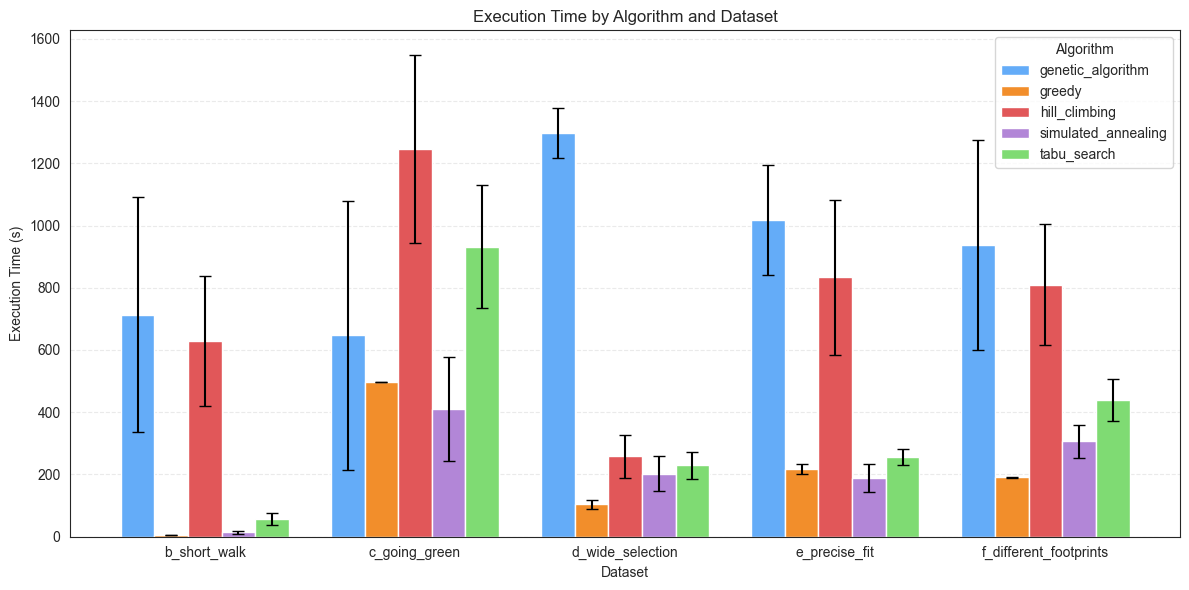

In [83]:
# Ensure the time column is numeric
df["Time (s)"] = pd.to_numeric(df["Time (s)"], errors="coerce")

# Remove invalid rows
df = df.dropna(subset=["Dataset", "Algorithm", "Time (s)"])

# Calculate mean and standard deviation
summary = (
    df.groupby(["Dataset", "Algorithm"])["Time (s)"]
    .agg(["mean", "std"])
    .reset_index()
)

# Order of datasets and algorithms
dataset_order = sorted(summary["Dataset"].unique())
algorithm_order = sorted(summary["Algorithm"].unique())

# Create pivot tables
mean_table = summary.pivot(index="Dataset", columns="Algorithm", values="mean").reindex(dataset_order)
std_table  = summary.pivot(index="Dataset", columns="Algorithm", values="std").reindex(dataset_order)

# Ensure consistent column order
mean_table = mean_table.reindex(columns=algorithm_order)
std_table = std_table.reindex(columns=algorithm_order)

# Bar chart with error bars
x = np.arange(len(dataset_order))
n_algorithms = len(algorithm_order)
bar_width = 0.8 / n_algorithms

plt.figure(figsize=(12, 6))
sns.set_style("white")

colors = ["#64ACF8", "#F28E2B", "#E15759", "#B286D7", "#7FDB73"]

for i, alg in enumerate(algorithm_order):
    positions = x - 0.4 + bar_width/2 + i * bar_width
    plt.bar(
        positions,
        mean_table[alg],
        width=bar_width,
        yerr=std_table[alg],
        capsize=4,
        label=alg,
        color=colors[i]
    )

plt.xticks(x, dataset_order)
plt.xlabel("Dataset")
plt.ylabel("Execution Time (s)")
plt.title("Execution Time by Algorithm and Dataset")
plt.legend(title="Algorithm")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

## Peak Memory by Algorithm and Dataset

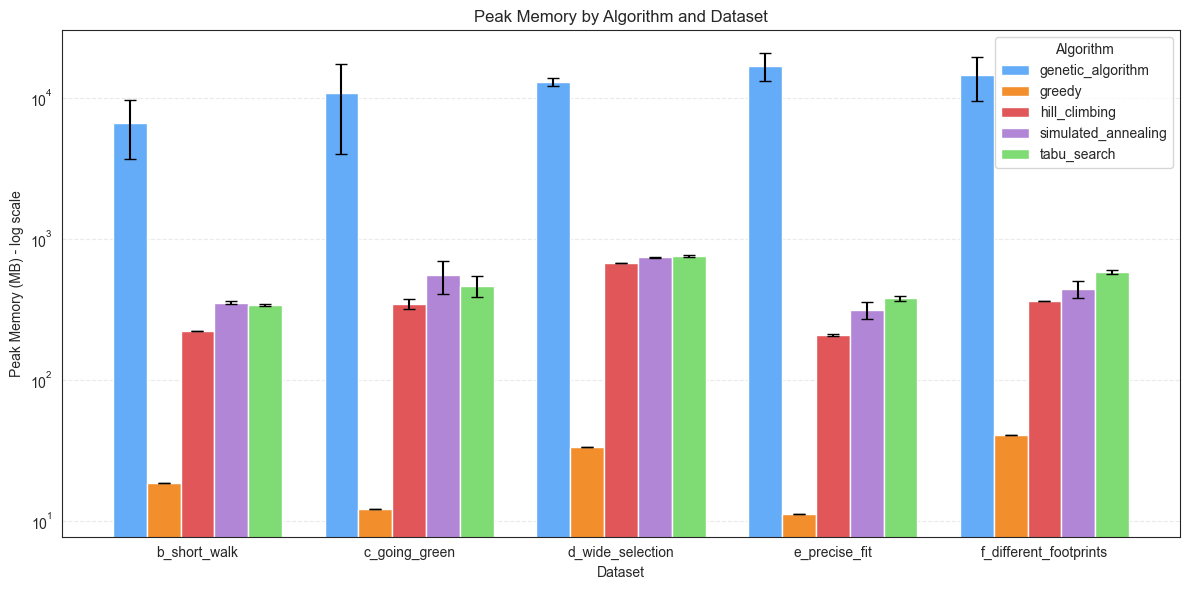

In [84]:
df["Peak Memory (MB)"] = pd.to_numeric(df["Peak Memory (MB)"], errors="coerce")
df = df.dropna(subset=["Dataset", "Algorithm", "Peak Memory (MB)"])

summary = (
    df.groupby(["Dataset", "Algorithm"])["Peak Memory (MB)"]
    .agg(["mean", "std"])
    .reset_index()
)

dataset_order = sorted(summary["Dataset"].unique())
algorithm_order = sorted(summary["Algorithm"].unique())

mean_table = summary.pivot(index="Dataset", columns="Algorithm", values="mean").reindex(dataset_order)
std_table = summary.pivot(index="Dataset", columns="Algorithm", values="std").reindex(dataset_order)

mean_table = mean_table.reindex(columns=algorithm_order)
std_table = std_table.reindex(columns=algorithm_order)


x = np.arange(len(dataset_order))
n_algorithms = len(algorithm_order)
bar_width = 0.8 / n_algorithms

plt.figure(figsize=(12, 6))

for i, alg in enumerate(algorithm_order):
    positions = x - 0.4 + bar_width / 2 + i * bar_width
    plt.bar(
        positions,
        mean_table[alg],
        width=bar_width,
        yerr=std_table[alg],
        capsize=4,
        label=alg,
        color=colors[i]
    )

plt.xticks(x, dataset_order)
plt.xlabel("Dataset")
plt.ylabel("Peak Memory (MB) - log scale")
plt.title("Peak Memory by Algorithm and Dataset")
plt.yscale("log")
plt.legend(title="Algorithm")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

## Score by Algorithm and Dataset

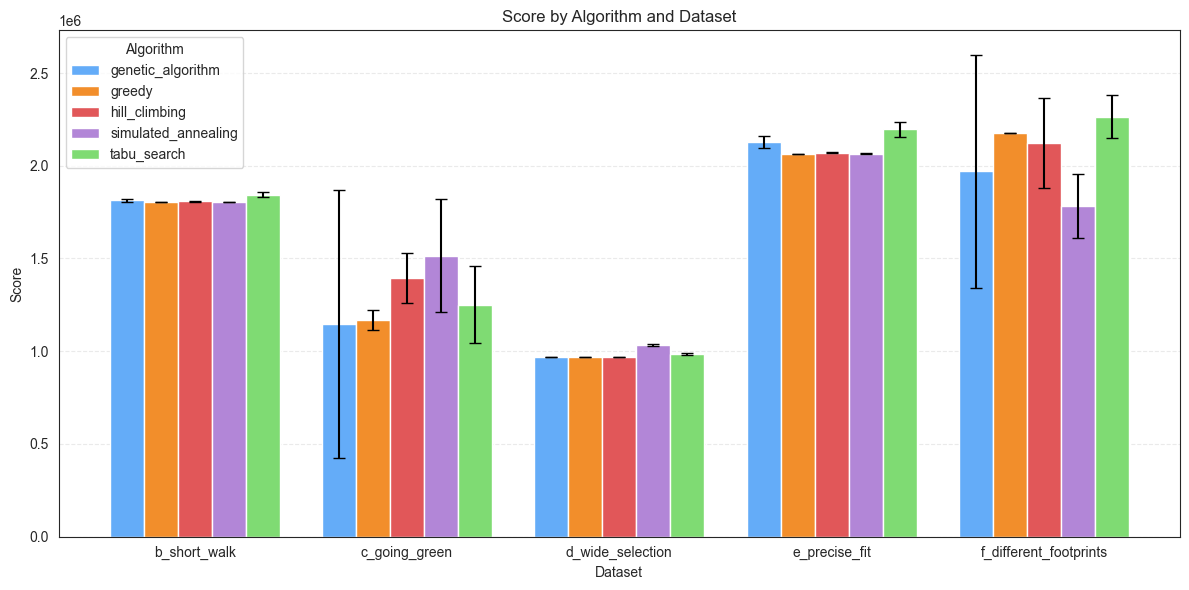

In [85]:
df["Score"] = pd.to_numeric(df["Score"], errors="coerce")

# Remove invalid rows
df = df.dropna(subset=["Dataset", "Algorithm", "Score"])

# Calculate mean and standard deviation
summary = (
    df.groupby(["Dataset", "Algorithm"])["Score"]
    .agg(["mean", "std"])
    .reset_index()
)

# Dataset and algorithm order
dataset_order = sorted(summary["Dataset"].unique())
algorithm_order = sorted(summary["Algorithm"].unique())

# Pivot tables
mean_table = summary.pivot(index="Dataset", columns="Algorithm", values="mean").reindex(dataset_order)
std_table = summary.pivot(index="Dataset", columns="Algorithm", values="std").reindex(dataset_order)

# Ensure consistent order
mean_table = mean_table.reindex(columns=algorithm_order)
std_table = std_table.reindex(columns=algorithm_order)

# Bar chart with error bars
x = np.arange(len(dataset_order))
n_algorithms = len(algorithm_order)
bar_width = 0.8 / n_algorithms

plt.figure(figsize=(12, 6))

for i, alg in enumerate(algorithm_order):
    positions = x - 0.4 + bar_width / 2 + i * bar_width
    plt.bar(
        positions,
        mean_table[alg],
        width=bar_width,
        yerr=std_table[alg],
        capsize=4,
        label=alg,
        color=colors[i % len(colors)]
    )

plt.xticks(x, dataset_order)
plt.xlabel("Dataset")
plt.ylabel("Score")
plt.title("Score by Algorithm and Dataset")
plt.legend(title="Algorithm")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


## Best Algorithm by Dataset

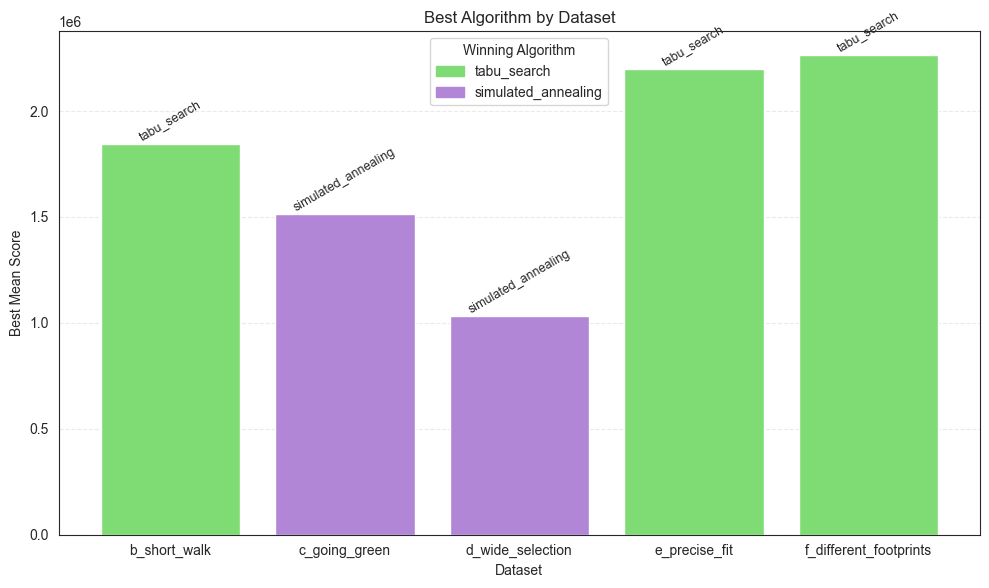

In [86]:
df["Score"] = pd.to_numeric(df["Score"], errors="coerce")
df = df.dropna(subset=["Dataset", "Algorithm", "Score"])

# Mean score by dataset and algorithm
summary = (
    df.groupby(["Dataset", "Algorithm"])["Score"]
    .mean()
    .reset_index()
)

# Choose the best algorithm per dataset
best_per_dataset = (
    summary.loc[summary.groupby("Dataset")["Score"].idxmax()]
    .sort_values("Dataset")
    .reset_index(drop=True)
)

# Colors per algorithm
algorithm_colors = {
    "genetic_algorithm": "#64ACF8",
    "greedy": "#F28E2B",
    "hill_climbing": "#E15759",
    "simulated_annealing": "#B286D7",
    "tabu_search": "#7FDB73",
}

bar_colors = [
    algorithm_colors.get(alg.lower(), "#999999")
    for alg in best_per_dataset["Algorithm"]
]

# Chart
plt.figure(figsize=(10, 6))

bars = plt.bar(
    best_per_dataset["Dataset"],
    best_per_dataset["Score"],
    color=bar_colors
)

# Write the algorithm name on top of each bar
for bar, alg in zip(bars, best_per_dataset["Algorithm"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        alg,
        ha="center",
        va="bottom",
        rotation=30,
        fontsize=9
    )

plt.xlabel("Dataset")
plt.ylabel("Best Mean Score")
plt.title("Best Algorithm by Dataset")
plt.grid(axis="y", linestyle="--", alpha=0.4)

# Manual legend
legend_handles = []
used = set()

for alg in best_per_dataset["Algorithm"].unique():
    color = algorithm_colors.get(alg.lower(), "#999999")
    if alg not in used:
        legend_handles.append(mpatches.Patch(color=color, label=alg))
        used.add(alg)

plt.legend(handles=legend_handles, title="Winning Algorithm")
plt.tight_layout()
plt.show()

## Maximum Delta vs Greedy by Dataset and Algorithm

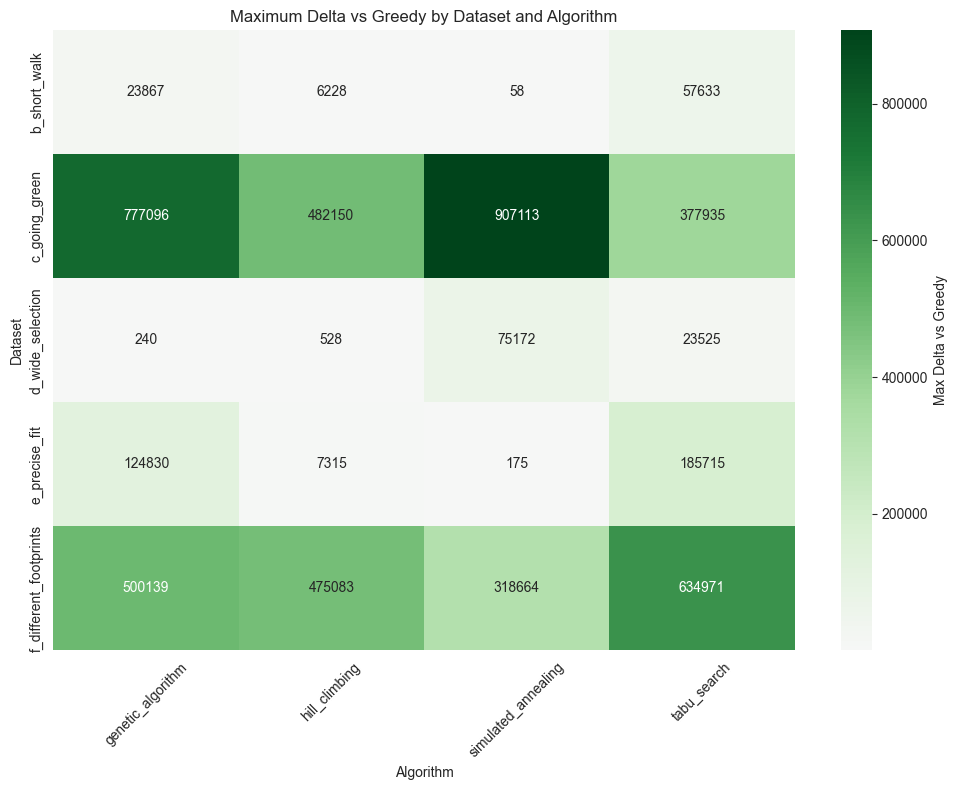

In [87]:
greedy_scores = {
    "b_short_walk": 1804115,
    "c_going_green": 1107401,
    "d_wide_selection": 967644,
    "e_precise_fit": 2066020,
    "f_different_footprints": 1714921
}

df['Greedy_Score'] = df['Dataset'].map(greedy_scores)

df['Delta_vs_Greedy'] = df['Score'] - df['Greedy_Score']

df_filtered = df[df['Algorithm'] != 'greedy']

df_max = df_filtered.groupby(['Dataset', 'Algorithm'])['Delta_vs_Greedy'].max().reset_index()

heatmap_data = df_max.pivot(index='Dataset', columns='Algorithm', values='Delta_vs_Greedy')

# Plot
plt.figure(figsize=(10, 8))
sns.heatmap(
    heatmap_data,
    annot=True, fmt=".0f",
    cmap="PRGn",
    center=0,
    cbar_kws={'label': 'Max Delta vs Greedy'}
)
plt.title("Maximum Delta vs Greedy by Dataset and Algorithm")
plt.ylabel("Dataset")
plt.xlabel("Algorithm")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Algorithm Score and Time by Scenario

In [88]:
# 1. Preparation
df["Score"] = pd.to_numeric(df["Score"], errors="coerce")
df["Time (s)"] = pd.to_numeric(df["Time (s)"], errors="coerce")
df = df.dropna(subset=["Algorithm", "Score", "Parameters"])

# 2. Parse Parameters column
def parse_params(param_str):
    if pd.isna(param_str):
        return {}

    s = str(param_str).strip()
    if not s:
        return {}

    parts = []
    current = ""
    depth = 0

    for ch in s:
        if ch in "[({":
            depth += 1
        elif ch in "])}":
            depth -= 1

        if ch == "," and depth == 0:
            parts.append(current.strip())
            current = ""
        else:
            current += ch

    if current.strip():
        parts.append(current.strip())

    result = {}
    for part in parts:
        if "=" not in part:
            continue

        key, value = part.split("=", 1)
        key = key.strip()
        value = value.strip()

        if value.lower() == "true":
            result[key] = True
        elif value.lower() == "false":
            result[key] = False
        else:
            try:
                result[key] = ast.literal_eval(value)
            except Exception:
                try:
                    result[key] = int(value)
                except Exception:
                    try:
                        result[key] = float(value)
                    except Exception:
                        result[key] = value

    return result


df["parsed_params"] = df["Parameters"].apply(parse_params)

IGNORE_PARAMS = {"seed"}

colors = {
    "genetic_algorithm": "#64ACF8",
    "hill_climbing": "#E15759",
    "simulated_annealing": "#B286D7",
    "tabu_search": "#7FDB73",
}

# 3. Helpers
def format_value(v):
    if isinstance(v, float):
        if abs(v) >= 1000:
            return f"{v:.0f}"
        return f"{v:.4g}"
    return str(v)


def prepare_scenarios(sub):
    sub = sub.copy()

    all_params = sorted({
        k for d in sub["parsed_params"]
        for k in d.keys()
        if k not in IGNORE_PARAMS
    })

    if len(all_params) == 0:
        sub["scenario"] = "Scenario 1"

        summary = pd.DataFrame({
            "scenario": ["Scenario 1"],
            "Score": [sub["Score"].mean()],
            "Time (s)": [sub["Time (s)"].mean()] if "Time (s)" in sub.columns else [None]
        })

        scenario_table = pd.DataFrame({
            "Scenario": ["Scenario 1"]
        })

        return sub, summary, scenario_table, all_params

    sub["config_tuple"] = sub["parsed_params"].apply(
        lambda d: tuple((k, d.get(k, None)) for k in all_params)
    )

    unique_configs = pd.Series(sub["config_tuple"].unique()).tolist()

    scenario_map = {
        cfg: f"Scenario {i+1}"
        for i, cfg in enumerate(unique_configs)
    }

    sub["scenario"] = sub["config_tuple"].map(scenario_map)

    agg_dict = {"Score": "mean"}
    if "Time (s)" in sub.columns:
        agg_dict["Time (s)"] = "mean"

    summary = (
        sub.groupby("scenario")
        .agg(agg_dict)
        .reset_index()
    )

    summary["scenario_num"] = summary["scenario"].str.extract(r"(\d+)").astype(int)
    summary = summary.sort_values("scenario_num").drop(columns="scenario_num")

    rows = []
    for cfg, scenario_name in scenario_map.items():
        row = {"Scenario": scenario_name}
        for k, v in cfg:
            row[k] = format_value(v)
        rows.append(row)

    scenario_table = pd.DataFrame(rows)
    scenario_table["scenario_num"] = scenario_table["Scenario"].str.extract(r"(\d+)").astype(int)
    scenario_table = scenario_table.sort_values("scenario_num").drop(columns="scenario_num")

    return sub, summary, scenario_table, all_params


def draw_scenario_table(ax_table, scenario_table):
    ax_table.axis("off")

    scenario_table_t = scenario_table.set_index("Scenario").T
    scenario_table_t.insert(0, "Parameter", scenario_table_t.index)

    table = ax_table.table(
        cellText=scenario_table_t.values,
        colLabels=scenario_table_t.columns,
        cellLoc="center",
        loc="center"
    )

    ncols = len(scenario_table_t.columns)
    first_col_width = 0.27
    other_col_width = (1.0 - first_col_width) / (ncols - 1)

    for (row, col), cell in table.get_celld().items():
        if col == 0:
            cell.set_width(first_col_width)
        else:
            cell.set_width(other_col_width)

    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1, 1.5)

    # Force rendering to get the real table position
    fig = ax_table.figure
    fig.canvas.draw()

    renderer = fig.canvas.get_renderer()
    bbox_display = table.get_window_extent(renderer=renderer)

    # Convert table bbox to axis coordinates
    bbox_axes = bbox_display.transformed(ax_table.transAxes.inverted())

    # Title positioned relative to the real table position
    x_center = (bbox_axes.x0 + bbox_axes.x1) / 2
    y_top = bbox_axes.y1

    ax_table.text(
        x_center,
        y_top + 0.03,   # distance above the table
        "Scenario Parameters",
        ha="center",
        va="bottom",
        fontsize=17,
        transform=ax_table.transAxes
    )


# 4. Function: score + time
def plot_score_time_with_scenarios(sub, alg_name, title_suffix=""):
    if sub.empty:
        return

    sub = sub.dropna(subset=["Time (s)"]).copy()
    if sub.empty:
        return

    _, summary, scenario_table, _ = prepare_scenarios(sub)

    score_summary = summary.sort_values("Score").copy()
    score_order = score_summary["scenario"].tolist()
    time_summary = summary.set_index("scenario").loc[score_order].reset_index()

    fig = plt.figure(figsize=(16, max(7, 1.8 * len(score_summary) + 3)))
    gs = fig.add_gridspec(
        2, 2,
        width_ratios=[1.2, 1],
        height_ratios=[1, 1]
    )

    ax_score = fig.add_subplot(gs[0, 0])
    ax_time = fig.add_subplot(gs[1, 0])
    ax_table = fig.add_subplot(gs[:, 1])

    ax_score.barh(
        score_summary["scenario"],
        score_summary["Score"],
        color=colors.get(alg_name, "#999999")
    )
    ax_score.set_xlabel("Average Score")
    ax_score.set_ylabel("Scenario")
    ax_score.set_title(f"{alg_name}{title_suffix} - Score by Scenario")
    ax_score.grid(axis="x", linestyle="--", alpha=0.4)

    ax_time.barh(
        time_summary["scenario"],
        time_summary["Time (s)"],
        color=colors.get(alg_name, "#999999")
    )
    ax_time.set_xlabel("Average Time (s)")
    ax_time.set_ylabel("Scenario")
    ax_time.set_title(f"{alg_name}{title_suffix} - Time by Scenario")
    ax_time.grid(axis="x", linestyle="--", alpha=0.4)

    draw_scenario_table(ax_table, scenario_table)

    plt.tight_layout()
    plt.show()


# 5. Function: score only
def plot_score_only_with_scenarios(sub, alg_name, title_suffix=""):
    if sub.empty:
        return

    _, summary, scenario_table, _ = prepare_scenarios(sub)

    score_summary = summary.sort_values("Score").copy()

    fig = plt.figure(figsize=(16, max(5, 1.2 * len(score_summary) + 2)))
    gs = fig.add_gridspec(1, 2, width_ratios=[1.2, 1])

    ax_score = fig.add_subplot(gs[0, 0])
    ax_table = fig.add_subplot(gs[0, 1])

    ax_score.barh(
        score_summary["scenario"],
        score_summary["Score"],
        color=colors.get(alg_name, "#999999")
    )
    ax_score.set_xlabel("Average Score")
    ax_score.set_ylabel("Scenario")
    ax_score.set_title(f"{alg_name}{title_suffix} - Configuration Comparison")
    ax_score.grid(axis="x", linestyle="--", alpha=0.4)

    draw_scenario_table(ax_table, scenario_table)

    plt.tight_layout()
    plt.show()

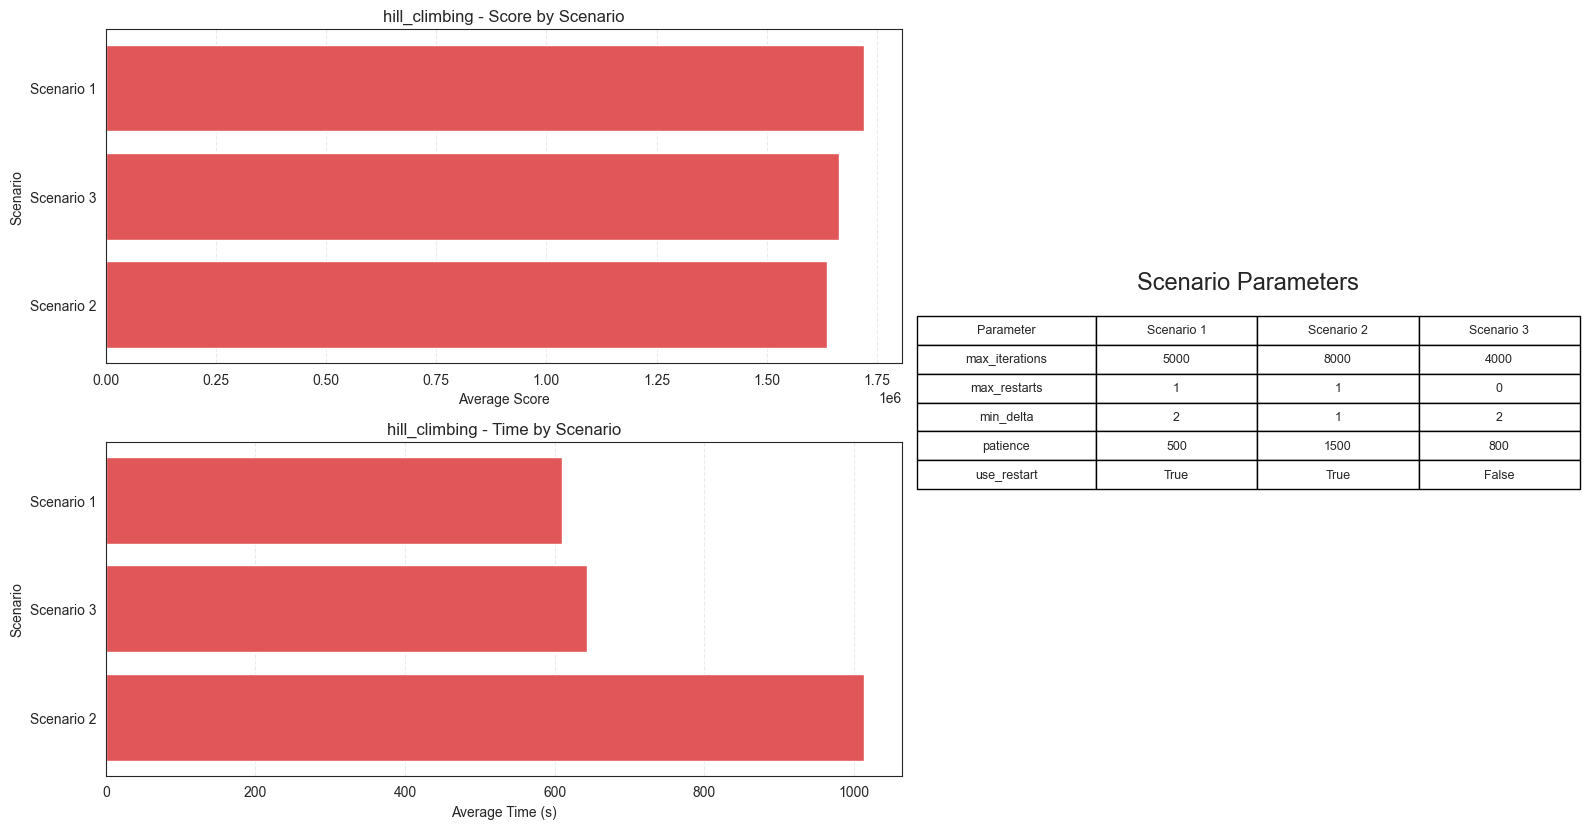

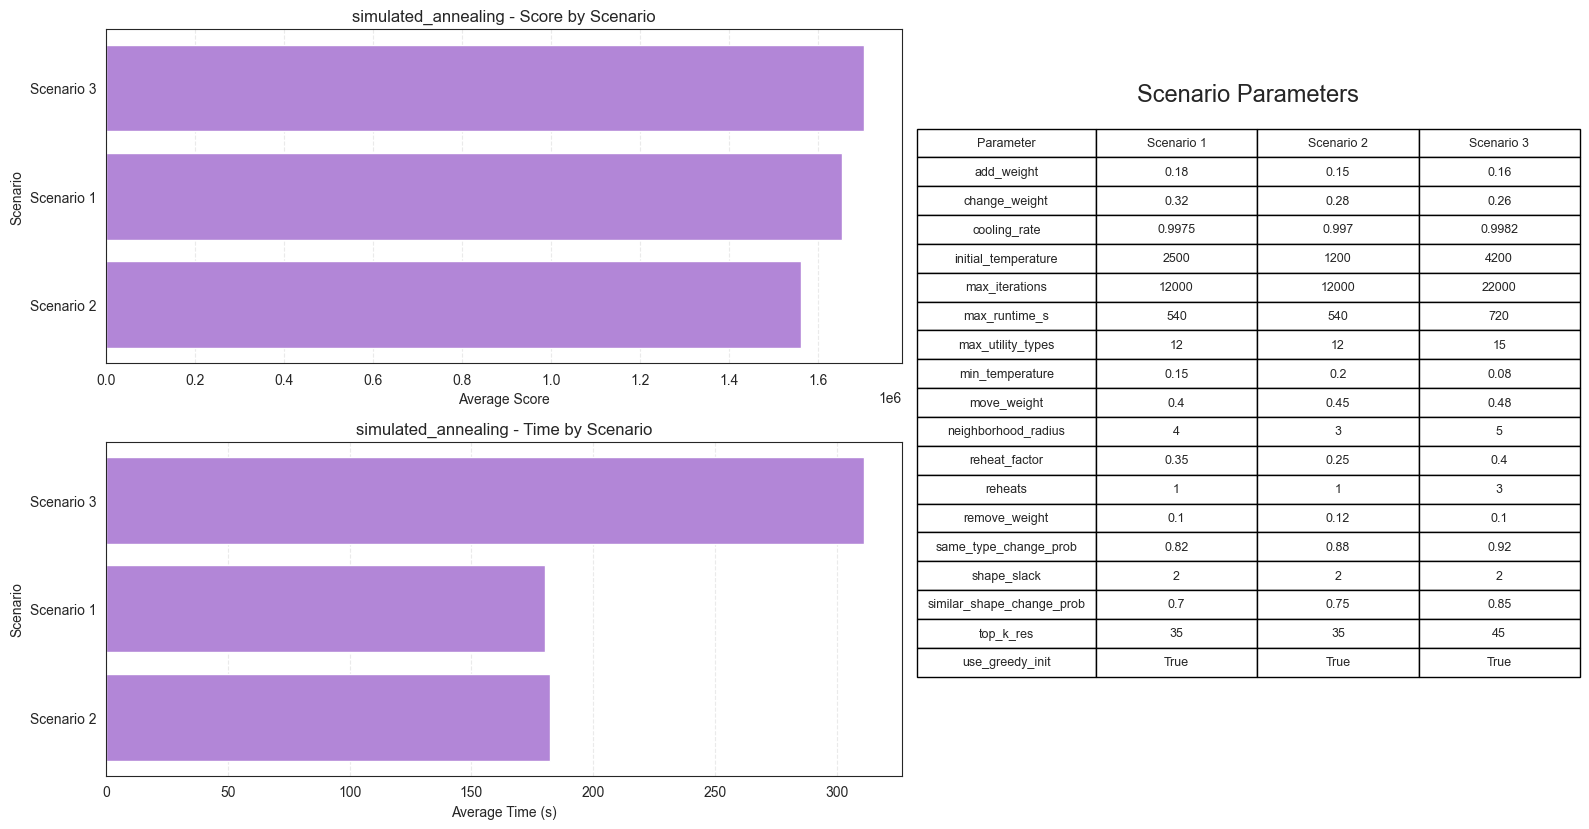

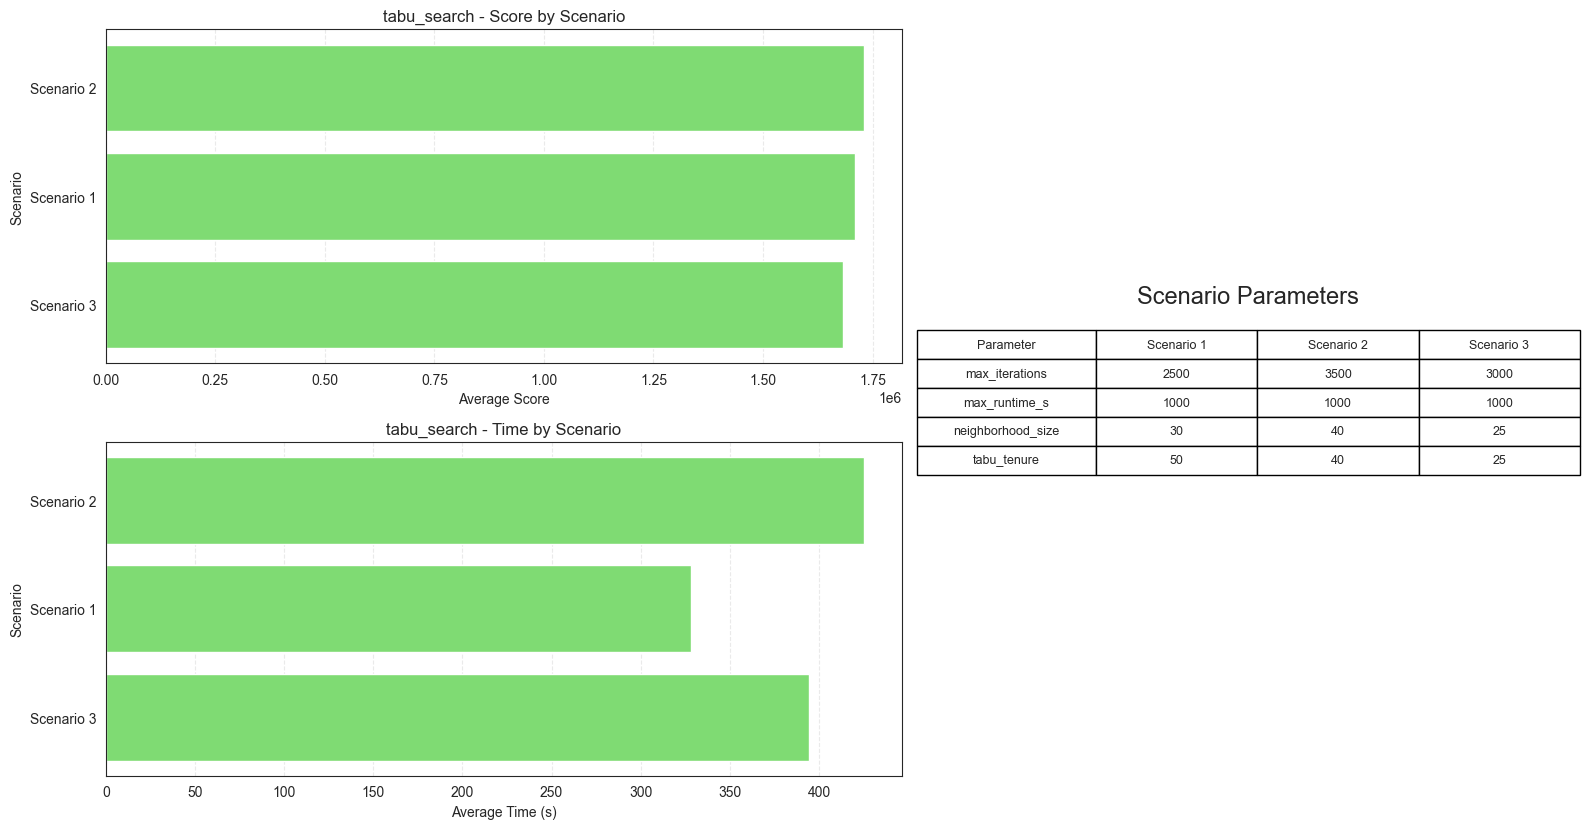

In [89]:
for alg in ["hill_climbing", "simulated_annealing", "tabu_search"]:
    sub_alg = df[df["Algorithm"] == alg].copy()
    plot_score_time_with_scenarios(sub_alg, alg)

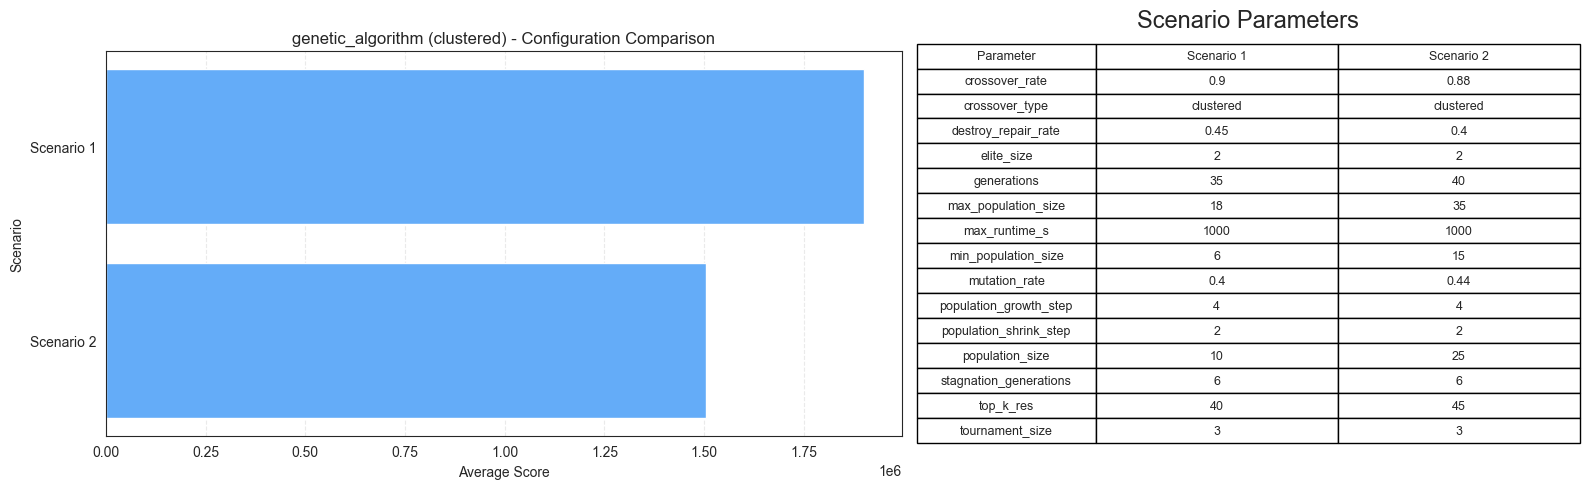

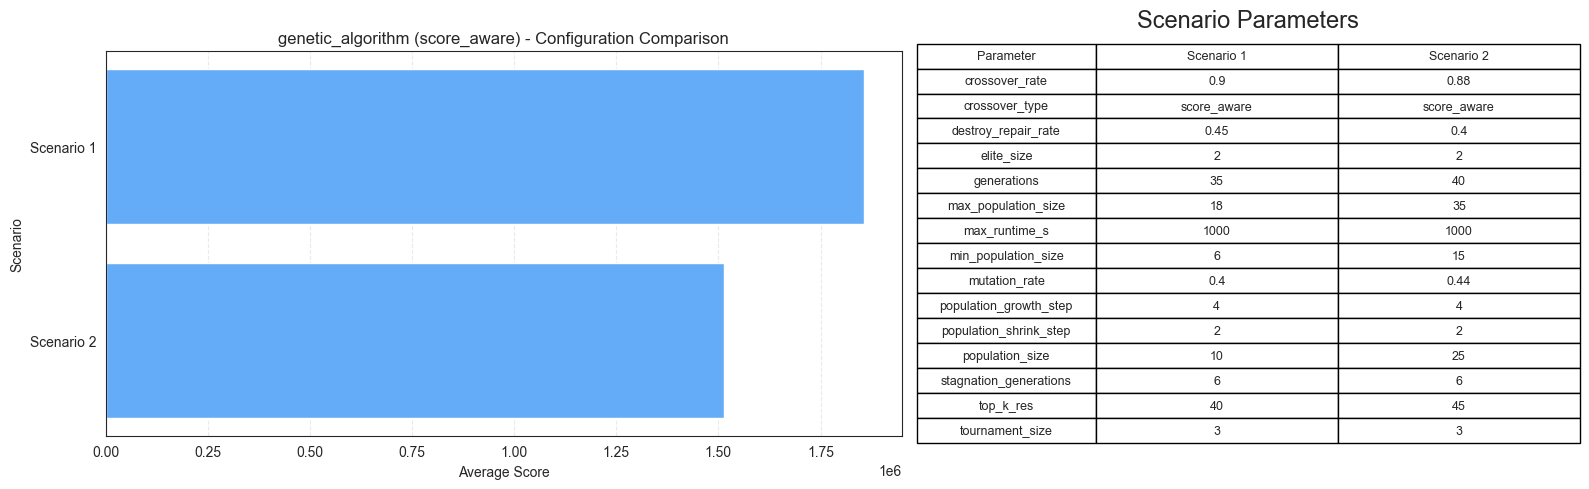

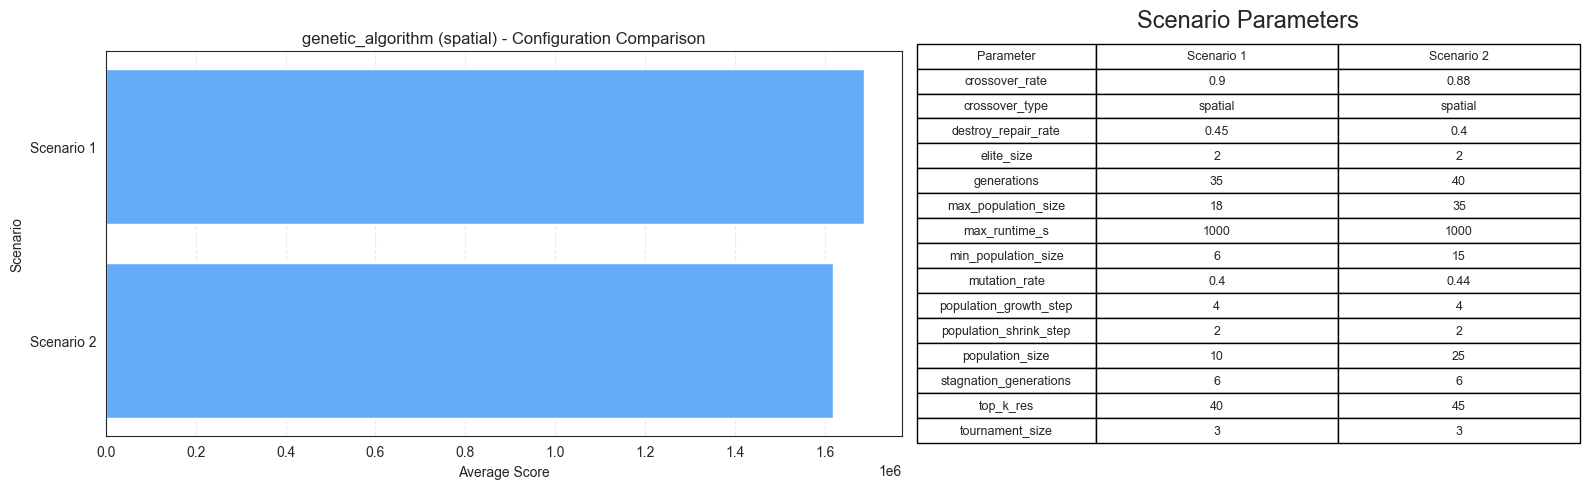

In [90]:
sub_ga = df[df["Algorithm"] == "genetic_algorithm"].copy()

crossovers = sorted(
    sub_ga["parsed_params"]
    .apply(lambda d: d.get("crossover_type", None))
    .dropna()
    .unique()
)

for crossover in crossovers:
    sub_cross = sub_ga[
        sub_ga["parsed_params"].apply(lambda d: d.get("crossover_type", None) == crossover)
    ].copy()

    plot_score_only_with_scenarios(
        sub_cross,
        "genetic_algorithm",
        title_suffix=f" ({crossover})"
    )

## Final Figure

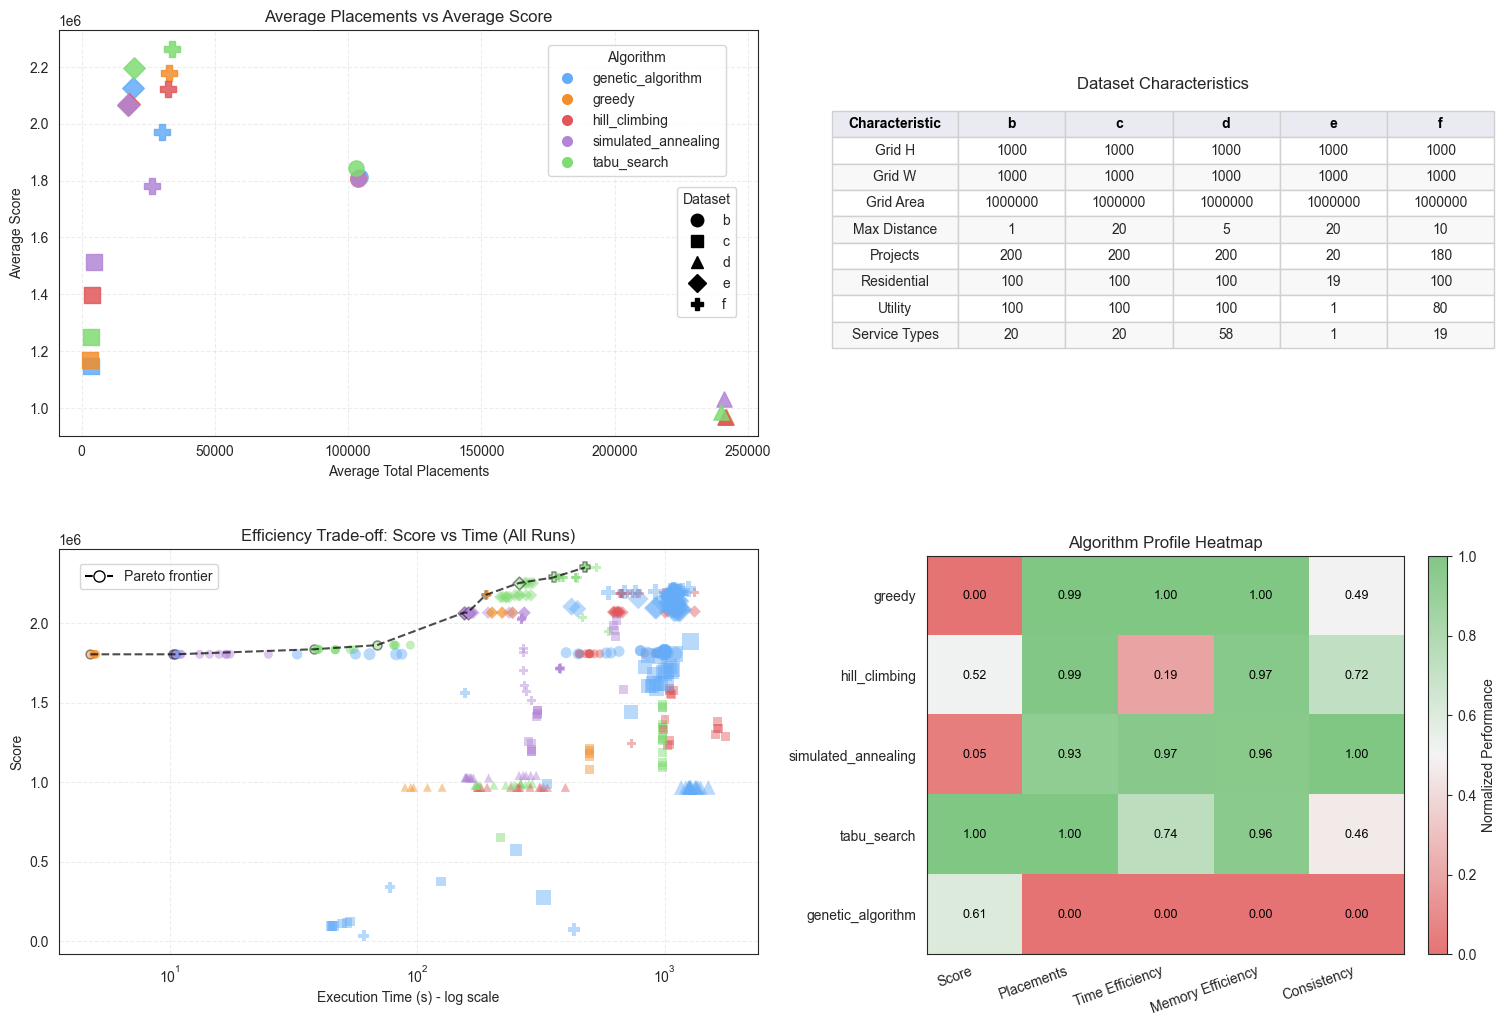

In [91]:
# 1. Data Preparation
df["Total Placements"] = pd.to_numeric(df["Total Placements"], errors="coerce")
df["Score"] = pd.to_numeric(df["Score"], errors="coerce")
df["Time (s)"] = pd.to_numeric(df["Time (s)"], errors="coerce")
df["Peak Memory (MB)"] = pd.to_numeric(df["Peak Memory (MB)"], errors="coerce")

df = df.dropna(subset=["Dataset", "Algorithm", "Total Placements", "Score", "Time (s)", "Peak Memory (MB)"])

# keep only the dataset letter
df["Dataset"] = df["Dataset"].astype(str).str.split("_").str[0]

# 2. Data for chart 1
summary = (
    df.groupby(["Dataset", "Algorithm"])[["Total Placements", "Score"]]
    .mean()
    .reset_index()
)

# 3. Data for table
dataset_table = (
    df.groupby("Dataset")
    .agg({
        "grid_height": "first",
        "grid_width": "first",
        "grid_area": "first",
        "max_distance": "first",
        "num_projects": "first",
        "num_residential_projects": "first",
        "num_utility_projects": "first",
        "num_service_types": "first"
    })
    .reset_index()
)

dataset_table = dataset_table.rename(columns={
    "grid_height": "Grid H",
    "grid_width": "Grid W",
    "grid_area": "Grid Area",
    "max_distance": "Max Distance",
    "num_projects": "Projects",
    "num_residential_projects": "Residential",
    "num_utility_projects": "Utility",
    "num_service_types": "Service Types"
})

dataset_table = dataset_table.sort_values("Dataset").reset_index(drop=True)

# 4. Styles
algorithms = sorted(df["Algorithm"].unique())
datasets = sorted(df["Dataset"].unique())

colors = {
    "genetic_algorithm": "#64ACF8",
    "greedy": "#F28E2B",
    "hill_climbing": "#E15759",
    "simulated_annealing": "#B286D7",
    "tabu_search": "#7FDB73",
}

markers = ["o", "s", "^", "D", "P", "X", "v", "<", ">"]
dataset_markers = {d: markers[i % len(markers)] for i, d in enumerate(datasets)}

# 5. Data for chart 2 (Pareto)
mem = df["Peak Memory (MB)"]
sizes = 40 + 120 * (mem - mem.min()) / (mem.max() - mem.min())
df["point_size"] = sizes

def is_pareto_efficient(points_time, points_score):
    n = len(points_time)
    efficient = np.ones(n, dtype=bool)

    for i in range(n):
        for j in range(n):
            if i == j:
                continue

            better_or_equal = (
                points_time[j] <= points_time[i] and
                points_score[j] >= points_score[i]
            )
            strictly_better = (
                points_time[j] < points_time[i] or
                points_score[j] > points_score[i]
            )

            if better_or_equal and strictly_better:
                efficient[i] = False
                break

    return efficient

df["pareto"] = is_pareto_efficient(
    df["Time (s)"].values,
    df["Score"].values
)

pareto_points = df[df["pareto"]].sort_values("Time (s)")

# 6. Data for heatmap
algo_summary = (
    df.groupby("Algorithm")
    .agg({
        "Score": ["mean", "std"],
        "Total Placements": "mean",
        "Time (s)": "mean",
        "Peak Memory (MB)": "mean"
    })
)

algo_summary.columns = [
    "Mean Score",
    "Std Score",
    "Mean Placements",
    "Mean Time",
    "Mean Memory"
]
algo_summary = algo_summary.reset_index()

algo_summary["CV Score"] = algo_summary["Std Score"] / algo_summary["Mean Score"]
algo_summary["CV Score"] = algo_summary["CV Score"].replace([np.inf, -np.inf], np.nan).fillna(0)

def normalize_positive(series):
    smin, smax = series.min(), series.max()
    if smax == smin:
        return pd.Series([1.0] * len(series), index=series.index)
    return (series - smin) / (smax - smin)

def normalize_negative(series):
    smin, smax = series.min(), series.max()
    if smax == smin:
        return pd.Series([1.0] * len(series), index=series.index)
    return (smax - series) / (smax - smin)

heatmap_df = pd.DataFrame({
    "Algorithm": algo_summary["Algorithm"],
    "Score": normalize_positive(algo_summary["Mean Score"]),
    "Placements": normalize_positive(algo_summary["Mean Placements"]),
    "Time Efficiency": normalize_negative(algo_summary["Mean Time"]),
    "Memory Efficiency": normalize_negative(algo_summary["Mean Memory"]),
    "Consistency": normalize_negative(algo_summary["CV Score"]),
})

algorithm_order = [
    "greedy",
    "hill_climbing",
    "simulated_annealing",
    "tabu_search",
    "genetic_algorithm"
]
heatmap_df["Algorithm"] = pd.Categorical(
    heatmap_df["Algorithm"],
    categories=algorithm_order,
    ordered=True
)
heatmap_df = heatmap_df.sort_values("Algorithm")
heatmap_matrix = heatmap_df.set_index("Algorithm")

custom_cmap = LinearSegmentedColormap.from_list(
    "red_yellow_green_soft",
    ["#E57373", "#F4F4F4", "#81C784"]
)

# 7. Final Figure
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(
    2, 2,
    width_ratios=[1.42, 1.18],
    height_ratios=[1, 1],
    wspace=0.18,
    hspace=0.28
)

ax1 = fig.add_subplot(gs[0, 0])   # placements vs score
ax2 = fig.add_subplot(gs[1, 0])   # score vs time

right_gs = gs[:, 1].subgridspec(
    2, 1,
    height_ratios=[1.0, 1.0],
    hspace=0.32
)

ax_table = fig.add_subplot(right_gs[0, 0])
ax_heat = fig.add_subplot(right_gs[1, 0])

# Chart 1: Average Placements vs Average Score
for _, row in summary.iterrows():
    ax1.scatter(
        row["Total Placements"],
        row["Score"],
        color=colors.get(row["Algorithm"], "#999999"),
        marker=dataset_markers[row["Dataset"]],
        s=120,
        alpha=0.85
    )

ax1.set_xlabel("Average Total Placements")
ax1.set_ylabel("Average Score")
ax1.set_title("Average Placements vs Average Score")
ax1.grid(True, linestyle="--", alpha=0.35)

# legends inside the top-left chart
algorithm_handles = [
    Line2D(
        [0], [0],
        marker='o',
        color='w',
        label=alg,
        markerfacecolor=colors.get(alg, "#999999"),
        markersize=9
    )
    for alg in algorithms
]

dataset_handles = [
    Line2D(
        [0], [0],
        marker=dataset_markers[ds],
        color='black',
        linestyle='None',
        label=ds,
        markersize=9
    )
    for ds in datasets
]

legend_alg = ax1.legend(
    handles=algorithm_handles,
    title="Algorithm",
    loc="upper left",
    bbox_to_anchor=(0.69, 0.98),
    frameon=True
)

legend_data = ax1.legend(
    handles=dataset_handles,
    title="Dataset",
    loc="upper left",
    bbox_to_anchor=(0.875, 0.63),
    frameon=True
)

ax1.add_artist(legend_alg)

# Chart 2: Efficiency Trade-off
for _, row in df.iterrows():
    edgecolor = "black" if row["pareto"] else "none"
    linewidth = 1.1 if row["pareto"] else 0.0

    ax2.scatter(
        row["Time (s)"],
        row["Score"],
        color=colors.get(row["Algorithm"], "#999999"),
        marker=dataset_markers[row["Dataset"]],
        s=row["point_size"],
        alpha=0.45,
        edgecolors=edgecolor,
        linewidths=linewidth
    )

if len(pareto_points) > 1:
    ax2.plot(
        pareto_points["Time (s)"],
        pareto_points["Score"],
        linestyle="--",
        linewidth=1.5,
        color="black",
        alpha=0.7
    )

ax2.set_xscale("log")
ax2.set_xlabel("Execution Time (s) - log scale")
ax2.set_ylabel("Score")
ax2.set_title("Efficiency Trade-off: Score vs Time (All Runs)")
ax2.grid(True, linestyle="--", alpha=0.35)

pareto_handle = Line2D(
    [0], [0],
    marker='o',
    color='black',
    markerfacecolor='white',
    linestyle='--',
    label='Pareto frontier',
    markersize=8
)

ax2.legend(
    handles=[pareto_handle],
    loc="upper left",
    bbox_to_anchor=(0.02, 0.98),
    frameon=True
)

# Table
ax_table.axis("off")
ax_table.set_title("Dataset Characteristics", pad=1, y=0.85)

dataset_table_t = dataset_table.set_index("Dataset").T
dataset_table_t.insert(0, "Characteristic", dataset_table_t.index)

table = ax_table.table(
    cellText=dataset_table_t.values,
    colLabels=dataset_table_t.columns,
    cellLoc="center",
    loc="center"
)

ncols = len(dataset_table_t.columns)
first_col_width = 0.19
other_col_width = (1.0 - first_col_width) / (ncols - 1)

for (row, col), cell in table.get_celld().items():
    if col == 0:
        cell.set_width(first_col_width)
    else:
        cell.set_width(other_col_width)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.14, 1.58)

for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor("#D0D0D0")
    if row == 0:
        cell.set_text_props(weight="bold", color="black")
        cell.set_facecolor("#EAEAF2")
    else:
        cell.set_facecolor("#F8F8F8" if row % 2 == 0 else "white")

# Heatmap
im = ax_heat.imshow(
    heatmap_matrix.values,
    aspect="auto",
    cmap=custom_cmap,
    vmin=0,
    vmax=1
)

ax_heat.set_xticks(range(len(heatmap_matrix.columns)))
ax_heat.set_xticklabels(heatmap_matrix.columns, rotation=20, ha="right")
ax_heat.set_yticks(range(len(heatmap_matrix.index)))
ax_heat.set_yticklabels(heatmap_matrix.index)
ax_heat.tick_params(axis='y', pad=4)
ax_heat.set_title("Algorithm Profile Heatmap")

for i in range(heatmap_matrix.shape[0]):
    for j in range(heatmap_matrix.shape[1]):
        value = heatmap_matrix.iloc[i, j]
        ax_heat.text(
            j, i, f"{value:.2f}",
            ha="center", va="center",
            fontsize=9,
            color="black"
        )

cbar = fig.colorbar(im, ax=ax_heat, fraction=0.045, pad=0.04)
cbar.set_label("Normalized Performance")

# slightly shrink heatmap to the right
pos = ax_heat.get_position()
ax_heat.set_position([pos.x0 + 0.03, pos.y0, pos.width - 0.03, pos.height])

plt.show()